# Prelim

In [ ]:
library(tidyverse)
library(gprofiler2)
library(stringr)
library(Dict)
library(readxl)
library(ggplot2)
library(gprofiler2)

fig_size <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
}

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Reading and cleaning data

## Keys (filenames, trait IDs, etc.)

In [37]:
burden_trait_keys = dict(
    trunk_fat_mass = 23128,
    bmi = 23104, # Pividori used this, not 21001
    thigh_muscle_volume = 22409,
    leg_fat_free_mass = 22409,
    leg_predicted_mass = 23114,
    trunk_predicted_mass = 23130,
    rbc_count = 30010,
    hematocrit = 30030,
    lymphocyte_count = 30120,
    total_cholesterol = 30690,
    ldl = 30780,
    # weight = 'weight_custom',
    weight = 23098, # For some reason Pividori used this, not 21002
    platelet_distribution_width = 30110,
    mean_platelet_volume = 30100,
    mean_corpuscular_volume = 30040,
    mean_corpuscular_haemoglobin_concentration = 30060,
    height = 50,
    height_age_10 = 1697,
    size_age_10 = 1687,
    fat_free_mass = 23101
)

pividori_trait_keys = dict(
    trunk_fat_mass = 23128,
    bmi = 23104, # Pividori used this, not 21001
    thigh_muscle_volume = 22409,
    leg_fat_free_mass = 22409,
    leg_predicted_mass = 23114,
    trunk_predicted_mass = 23130,
    rbc_count = 30010,
    lymphocyte_count = 30120,
    total_cholesterol = '6153_100', # Using self-reported high cholesterol instead of 30690
    ldl = 30780,
    # weight = 'weight_custom',
    weight = 23098, # For some reason Pividori used this, not 21002
    platelet_distribution_width = 30110,
    mean_platelet_volume = 30100,
    mean_corpuscular_volume = 30040,
    mean_corpuscular_haemoglobin_concentration = 30060,
    height = 50,
    height_age_10 = 1697,
    size_age_10 = 1687,
    fat_free_mass = 23101
)

barbeira_trait_keys = dict(
    bmi = 'BMI',
    rbc_count = 'Red_blood_cell_count',
    ldl = 'MAGNETIC_LDL.C',
    thigh_muscle_volume = '',
    trunk_fat_mass = '',
    leg_fat_mass = '',
    arm_fat_mass = '',
    fat_mass = '',
    trunk_predicted_mass = '',
    leg_predicted_mass = '',
    arm_predicted_mass = '',
    lymphocyte_count = 'Lymphocyte_counts',
    mean_corpuscular_haemoglobin_concentration = '',
    weight = '',
    leg_fat_free_mass = '',
    fat_free_mass = '',
    total_cholesterol = 'UKB_20002_1473_self_reported_high_cholesterol',
    size_age_10 = ''
)

human_gwas_index = dict(
    bmi = 'gwas-association-downloaded_2026-01-09-EFO_0004340-withChildTraits.tsv',
    rbc_count = 'gwas-association-downloaded_2026-01-10-EFO_0004305.tsv',
    hematocrit = 'gwas-association-downloaded_2026-01-12-EFO_0004348.tsv',
    ldl = 'gwas-association-downloaded_2026-01-10-EFO_0004611-withChildTraits.tsv',
    total_cholesterol = 'gwas-association-downloaded_2026-01-12-EFO_0004574-withChildTraits.tsv',
    thigh_muscle_volume = 'gwas-association-downloaded_2026-01-10-EFO_0020107-withChildTraits.tsv',
    trunk_fat_mass = 'gwas-association-downloaded_2026-01-10-OBA_VT0010482-withChildTraits.tsv',
    leg_fat_mass = 'gwas-association-downloaded_2026-01-10-OBA_VT0010482-withChildTraits.tsv',
    arm_fat_mass = 'gwas-association-downloaded_2026-01-10-OBA_VT0010482-withChildTraits.tsv',
    fat_mass = 'gwas-association-downloaded_2026-01-10-OBA_VT0010482-withChildTraits.tsv',
    # trunk_predicted_mass = 'gwas-association-downloaded_2026-01-10-EFO_0004324-withChildTraits.tsv',
    # leg_predicted_mass = 'gwas-association-downloaded_2026-01-10-EFO_0004324-withChildTraits.tsv',
    # arm_predicted_mass = 'gwas-association-downloaded_2026-01-10-EFO_0004324-withChildTraits.tsv',
    lymphocyte_count = 'gwas-association-downloaded_2026-01-10-EFO_0004587-withChildTraits.tsv',
    mean_corpuscular_haemoglobin_concentration = 'gwas-association-downloaded_2026-01-10-EFO_0004509-withChildTraits.tsv',
    weight = 'gwas-association-downloaded_2026-01-10-EFO_0004338-withChildTraits.tsv',
    fat_free_mass = 'gwas-association-downloaded_2026-01-10-EFO_0004995.tsv',
    leg_fat_free_mass = 'gwas-association-downloaded_2026-01-10-EFO_0004995.tsv',
    trunk_predicted_mass = 'gwas-association-downloaded_2026-01-10-EFO_0004995.tsv',
    leg_predicted_mass = 'gwas-association-downloaded_2026-01-10-EFO_0004995.tsv',
    size_age_10 = 'gwas-association-downloaded_2026-01-12-EFO_0009819.tsv'
)

human_gwas_relevant_traits = dict(
    # bmi = c('longitudinal BMI measurement', 'body mass index'),
    bmi = c('body mass index'),
    rbc_count = c('Red blood cell count','Red blood cell erythrocyte count (UKB data field 30010)','red blood cell count (RBC, maximum, inv-norm transformed)','red blood cell count (RBC, mean, inv-norm transformed)','red blood cell count (RBC, minimum, inv-norm transformed)'),
    # ldl = c('LDL cholesterol change measurement','low density lipoprotein cholesterol measurement','total cholesterol measurement, triglyceride measurement, low density lipoprotein cholesterol measurement, high density lipoprotein cholesterol measurement','low density lipoprotein cholesterol measurement, lipid or lipoprotein measurement','low density lipoprotein cholesterol measurement, phospholipid level','free cholesterol measurement, low density lipoprotein cholesterol measurement','triglyceride measurement, low density lipoprotein cholesterol measurement','cholesteryl ester measurement, low density lipoprotein cholesterol measurement'),
    ldl = c('low density lipoprotein cholesterol measurement','low density lipoprotein cholesterol measurement, lipid or lipoprotein measurement'),
    trunk_fat_mass = c('Trunk fat mass (UKB data field 23128)','Body fat mass','Trunk fat mass adjusted for trunk lean mass','Fat body mass','Whole body fat mass (UKB data field 23100)','Trunk fat mass'),
    lymphocyte_count = c('Lymphocyte count (UKB data field 30120)','Lymphocyte count','Lymphocyte count variance','White blood cell count (lymphocyte)','Plasma Blast-Plasma Cell %lymphocyte','White blood cell count','lymphocyte (fraction, maximum, inv-norm transformed)','lymphocyte (absolute count, minimum, inv-norm transformed)','lymphocyte (absolute count, maximum, inv-norm transformed)','lymphocyte (absolute count, mean, inv-norm transformed)','lymphocyte (fraction, minimum, inv-norm transformed)','lymphocyte (fraction, mean, inv-norm transformed)'),
    mean_corpuscular_haemoglobin_concentration = c('Mean corpuscular hemoglobin concentration','Haemoglobin concentration (UKB data field 30020)','Hemoglobin concentration','Mean corpuscular haemoglobin concentration (UKB data field 30060)','mean corpuscular hemoglobin concentration (MCHC, mean, inv-norm transformed)','mean corpuscular hemoglobin concentration (MCHC, minimum, inv-norm transformed)','mean corpuscular hemoglobin concentration (MCHC, maximum, inv-norm transformed)'),
    weight = c('Weight','Weight (UKB data field 21002)','Weight (maximum, inv-normal transformed)','Weight (mean, inv-normal transformed)','Weight (minimum, inv-normal transformed)'),
    leg_fat_free_mass = c('Leg lean mass (fat adjusted)','Leg lean mass'),
    fat_free_mass = c('Trunk lean mass','Leg lean mass (fat adjusted)','Leg lean mass','Lean body mass'),
    size_age_10 = c('Body size at age 10')
)

# burden_test = dict(
#     bmi = 'gene-burden-results-exomes_pLoF_continuous-21001-both_sexes--irnt_2025_08_25_10_25_33.csv',
#     rbc_count = 'gene-burden-results-exomes_pLoF_continuous-30010-both_sexes--irnt_2025_09_22_13_16_17.csv',
#     ldl = 'gene-burden-results-exomes_pLoF_continuous-30780-both_sexes--irnt_2025_09_22_13_06_29.csv',
#     thigh_muscle_volume = 'gene-burden-results-exomes_pLoF_continuous-22409-both_sexes--irnt_2025_09_22_13_09_32.csv'
# )

pig_corresponding_traits = dict(
    bmi = c('ADG', 'DAYS', 'OBI'), # BFT is not good match
    rbc_count = c('RBC'), # There's an argument for using c('RBC', 'HCT') instead
    ldl = c('LDL'), # can also add 'CHOL' for total cholesterol
    total_cholesterol = c('CHOL'),
    thigh_muscle_volume = c('LMDEP', 'LMA'),
    leg_fat_free_mass = c('LMDEP', 'LMA'),
    fat_free_mass = c('LMDEP', 'LMA'),
    trunk_fat_mass = c('BFT'),
    lymphocyte_count = c('WBC'),
    mean_corpuscular_haemoglobin = c('MCH'),
    mean_corpuscular_haemoglobin_concentration = c('MCHC'),
    # weight = c('OBI', 'ADG', 'BFT', 'DAYS'),
    weight = c('OBI', 'ADG'),
    size_age_10 = c('ADG', 'DAYS'),
    size = c('ADG', 'DAYS', 'OBI'),
    composition = c('BFT', 'LMDEP', 'LMA'),
    cholesterol = c('CHOL', 'LDL')
)

## Functions for reading in

In [336]:
get_human_gwas = function(pheno, intergenic=T) {
    gwas_tab_cols = c('DISEASE/TRAIT','MAPPED_TRAIT','CHR_ID','CHR_POS','MAPPED_GENE','UPSTREAM_GENE_ID','DOWNSTREAM_GENE_ID','UPSTREAM_GENE_DISTANCE','DOWNSTREAM_GENE_DISTANCE','SNPS','INTERGENIC', 'SNP_GENE_IDS')
    gwas = read_tsv(
        paste0('~/comparative_colocalization/data/gwas_catalogue/', human_gwas_index[pheno]),
        col_names = T, show_col_types = F, guess_max = 10000
    ) %>% 
    dplyr::select(all_of(gwas_tab_cols)) %>%
    dplyr::filter(INTERGENIC == intergenic, !is.na(MAPPED_GENE), MAPPED_TRAIT %in% human_gwas_relevant_traits[pheno] | `DISEASE/TRAIT` %in% human_gwas_relevant_traits[pheno])

    if (nrow(gwas) == 0) {
        cat('Specified human GWAS traits unavailable. Returning all related traits.\n')
        gwas = read_tsv(
            paste0('~/comparative_colocalization/data/gwas_catalogue/', human_gwas_index[pheno]),
            col_names = T, show_col_types = F, guess_max = 10000
        ) %>% 
        dplyr::select(all_of(gwas_tab_cols)) %>%
        dplyr::filter(INTERGENIC == intergenic, !is.na(MAPPED_GENE))
    }
    if (intergenic) {
        tab_downstream = gwas %>%
            mutate(GENE_NAME = gsub('.* - ', '', MAPPED_GENE)) %>%
            dplyr::select(-UPSTREAM_GENE_ID, -UPSTREAM_GENE_DISTANCE, -MAPPED_GENE) %>%
            dplyr::rename(GENE_ID = DOWNSTREAM_GENE_ID, GENE_DISTANCE = DOWNSTREAM_GENE_DISTANCE)

        tab_upstream = gwas %>%
            mutate(GENE_NAME = gsub(' - .*', '', MAPPED_GENE)) %>%
            dplyr::select(-DOWNSTREAM_GENE_ID, -DOWNSTREAM_GENE_DISTANCE, -MAPPED_GENE) %>%
            dplyr::rename(GENE_ID = UPSTREAM_GENE_ID, GENE_DISTANCE = UPSTREAM_GENE_DISTANCE)

        tab = rbind(tab_downstream, tab_upstream) %>% dplyr::select(-SNP_GENE_IDS)
        return(tab)
    } else {
        tab = gwas %>% dplyr::rename(GENE_NAME = MAPPED_GENE, GENE_ID = SNP_GENE_IDS) %>% dplyr::select(-UPSTREAM_GENE_ID, -DOWNSTREAM_GENE_ID, -UPSTREAM_GENE_DISTANCE, -DOWNSTREAM_GENE_DISTANCE) %>% separate_longer_delim(c(GENE_NAME, GENE_ID), ', ')
        return(tab)
    }
}

get_human_burden = function(pheno, p_cutoff=1, verbose=F) {
    fl = list.files(path='~/comparative_colocalization/data/gene_table/', pattern=toString(burden_trait_keys[pheno]))
    if (verbose) print(fl)
    df = read.csv(paste0('~/comparative_colocalization/data/gene_table/', fl[1]), header=T, as.is=T) %>%
        filter(P.Value.Burden <= p_cutoff) %>%
        mutate(trait = pheno)

    if (length(fl) > 1) {
        for (i in c(2:length(fl))) {
            if (verbose) print(fl)
            df = rbind(
                df,
                read.csv(paste0('~/comparative_colocalization/data/gene_table/', fl[i]), header=T, as.is=T) %>%
                    filter(P.Value.Burden <= p_cutoff) %>%
                    mutate(trait = pheno)
            )
        }
    }
    return(df %>% distinct())
}

get_pividori_enloc = function(pheno, rcp_cutoff=0.5) {
    df = pividori_enloc %>% 
        filter(
            trait == pividori_trait_keys[pheno],
            rcp >= rcp_cutoff
        ) %>% 
        mutate(trait = pheno)
    return(df)
}

get_barbeira_enloc = function(pheno, rcp_cutoff=0.5) {
    if (barbeira_trait_keys[pheno] == '') return(barbeira_enloc[0, ])
    df = barbeira_enloc %>% 
        filter(
            grepl(barbeira_trait_keys[pheno], file),
            locus_rcp >= rcp_cutoff
        ) %>% 
        mutate(trait = pheno)
    return(df)
}

get_pig_enloc = function(pheno, rcp_cutoff=0.5) {
    df = pig_enloc %>% 
        filter(
            str_detect(trait, str_c(pig_corresponding_traits[pheno], collapse = '|')),
            !is.na(human_gene),
            rcp >= rcp_cutoff
        ) %>% 
        mutate(corresponding_trait = pheno)
    return(df)
}

get_pig_enloc_specific_trait = function(pheno, rcp_cutoff=0.5) {
    df = pig_enloc %>% 
        filter(
            str_detect(trait, str_c(pheno, collapse = '|')),
            !is.na(human_gene),
            rcp >= rcp_cutoff
        ) %>% 
        mutate(corresponding_trait = pheno)
    return(df)
}

In [ ]:
# read_tsv(
#         paste0('~/comparative_colocalization/data/gwas_catalogue/', human_gwas_index['bmi']),
#         col_names = T, show_col_types = F, guess_max = 10000
#     ) %>% select(SNP_GENE_IDS, MAPPED_GENE)

SNP_GENE_IDS,MAPPED_GENE
<chr>,<chr>
ENSG00000138031,ADCY3
ENSG00000140718,FTO
ENSG00000135298,ADGRB3
ENSG00000187323,DCC
ENSG00000277791,PSMB3
ENSG00000182732,RGS6
ENSG00000101638,ST8SIA5
ENSG00000145362,ANK2
ENSG00000170745,KCNS3


## Data to read in once

In [4]:
key_pividori_traits = read.csv('~/eqtl_selection/data/enloc/henloc/hukku_2021/1-s2.0-S0002929720304092-mmc21.csv', header=T)[, c(2:3)]
names(key_pividori_traits) = c('trait', 'description')
pividori_enloc = read.table('~/comparative_colocalization/data/intermediate_data/snps_elements_enrichments/henloc.tsv', header=T, as.is=T, sep='\t') %>%
    left_join(key_pividori_traits)

barbeira_enloc = read.table('~/eqtl_selection/data/enloc/henloc/barbeira_2021/results_eur/barbeira_2021_rcp_50.tsv', col.names=c('region', 'gene', 'locus_gwas_pip', 'locus_rcp', 'lead_coloc_snp', 'lead_snp_rcp', 'file')) %>%
    mutate(gene = gsub('\\..*', '', gene))

pig_enloc = read.table('~/comparative_colocalization/data/intermediate_data/snps_elements_enrichments/penloc.tsv', header=T, as.is=T, sep='\t')

pig_human_orthologs = gorth(
    pig_enloc$gene,
    source_organism = 'sscrofa',
    target_organism = 'hsapiens',
    numeric_ns = 'BIOGRID',
    mthreshold = Inf,
    filter_na = T
)

pig_enloc = pig_enloc %>%
    left_join(pig_human_orthologs %>% select(input, ortholog_name, ortholog_ensg) %>% dplyr::rename(gene=input, human_symbol=ortholog_name, human_gene=ortholog_ensg), by=join_by(gene), relationship='many-to-many') %>%
    distinct()

Joining with `by = join_by(trait)`


# Organizing data

In [10]:
assemble_row_gene = function(trait, rcp=0.5, burden_p=1e-5) {
    if (trait %in% pividori_trait_keys$keys) {
        piv = get_pividori_enloc(trait, rcp_cutoff = rcp)
    } else {
        piv = data.frame(gene=c('null'))
    }
    if (trait %in% barbeira_trait_keys$keys) {
        barb = get_barbeira_enloc(trait, rcp_cutoff = rcp)
    } else {
        barb = data.frame(gene=c('null'))
    }
    if (trait %in% pig_corresponding_traits$keys) {
        pig = get_pig_enloc(trait, rcp_cutoff = rcp)
    } else {
        pig = data.frame(human_gene=c('null'))
    }

    tab = data.frame(
        trait = c(trait),
        total_human = length(unique(c(
            piv %>% filter(gene != 'null') %>% pull(gene),
            barb %>% filter(gene != 'null') %>% pull(gene)
        ))),
        total_pig = c(pig %>% filter(human_gene != 'null') %>% distinct(human_gene) %>% nrow()))# ,
        # pividori_genes = c(burd %>% filter(Gene.Id %in% piv$gene) %>% distinct(Gene.Id) %>% pull(Gene.Id) %>% paste(collapse=',')),
        # barbeira_genes = c(burd %>% filter(Gene.Id %in% barb$gene) %>% distinct(Gene.Id) %>% pull(Gene.Id) %>% paste(collapse=',')),
        # pig_genes = c(burd %>% filter(Gene.Id %in% pig$human_gene) %>% distinct(Gene.Id) %>% pull(Gene.Id) %>% paste(collapse=','))
    return(tab)
}

In [323]:
human_size = unique(c(get_pividori_enloc('bmi')$gene, get_barbeira_enloc('bmi')$gene, get_pividori_enloc('weight')$gene, get_barbeira_enloc('weight')$gene))
pig_size = unique(c(get_pig_enloc('size')$human_gene))
human_composition = unique(c(get_pividori_enloc('trunk_fat_mass')$gene, get_barbeira_enloc('trunk_fat_mass')$gene, get_pividori_enloc('fat_free_mass')$gene, get_barbeira_enloc('fat_free_mass')$gene))
pig_composition = unique(c(get_pig_enloc('composition')$human_gene))
human_chol = unique(c(get_pividori_enloc('ldl')$gene, get_barbeira_enloc('ldl')$gene, get_pividori_enloc('total_cholesterol')$gene, get_barbeira_enloc('total_cholesterol')$gene))
pig_chol = unique(c(get_pig_enloc('cholesterol')$human_gene))
human_ldl = unique(c(get_pividori_enloc('ldl')$gene, get_barbeira_enloc('ldl')$gene))
pig_ldl = unique(c(get_pig_enloc('ldl')$human_gene))
human_tc = unique(c(get_pividori_enloc('total_cholesterol')$gene, get_barbeira_enloc('total_cholesterol')$gene))
pig_tc = unique(c(get_pig_enloc('total_cholesterol')$human_gene))
human_rbc = unique(c(get_pividori_enloc('rbc_count')$gene, get_barbeira_enloc('rbc_count')$gene))
pig_rbc = unique(c(get_pig_enloc('rbc_count')$human_gene))

cat('Size, human:\t',
    length(human_size))
cat('\nSize, pig:\t',
    length(pig_size))
cat('\nOverlap:\t',
    length(unique(intersect(human_size, pig_size))))
cat('\nComposition, human:\t',
    length(human_composition))
cat('\nComposition, pig:\t',
    length(pig_composition))
cat('\nOverlap:\t',
    length(unique(intersect(human_composition, pig_composition))))
cat('\nCholesterol, human:\t',
    length(human_chol))
cat('\nCholesterol, pig:\t',
    length(pig_chol))
cat('\nOverlap:\t',
    length(unique(intersect(human_chol, pig_chol))))
cat('\nTotal cholesterol, human:\t',
    length(human_tc))
cat('\nTotal cholesterol, pig:\t',
    length(pig_tc))
cat('\nOverlap:\t',
    length(unique(intersect(human_tc, pig_tc))))
cat('\nLDL, human:\t',
    length(human_ldl))
cat('\nLDL, pig:\t',
    length(pig_ldl))
cat('\nOverlap:\t',
    length(unique(intersect(human_ldl, pig_ldl))))
cat('\nRBC, human:\t',
    length(human_rbc))
cat('\nRBC, pig:\t',
    length(pig_rbc))
cat('\nOverlap:\t',
    length(unique(intersect(human_rbc, pig_rbc))))

Size, human:	 292
Size, pig:	 504
Overlap:	 7
Composition, human:	 231
Composition, pig:	 904
Overlap:	 7
Cholesterol, human:	 114
Cholesterol, pig:	 68
Overlap:	 1
Total cholesterol, human:	 113
Total cholesterol, pig:	 68
Overlap:	 1
LDL, human:	 15
LDL, pig:	 40
Overlap:	 0
RBC, human:	 439
RBC, pig:	 29
Overlap:	 1

# Create supplementary table 2

In [ ]:
get_human_ortholog = function(gene) {
    if (grepl('ENSG', gene)) {
        return(gene)
    } else {
        return(pig_human_orthologs$ortholog_ensg[which(pig_human_orthologs$input == gene)][1])
    }

}

get_human_ortholog_symbol = function(gene) {
    if (grepl('ENSG', gene)) {
        return(pig_human_orthologs$ortholog_name[which(pig_human_orthologs$ortholog_ensg == gene)][1])
    } else {
        return(pig_human_orthologs$ortholog_name[which(pig_human_orthologs$input == gene)][1])
    }

}

supp_tab = rbind(
    data.frame(category='size', species='human', trait='bmi', study='pividori', gene=get_pividori_enloc('bmi')$gene),
    data.frame(category='size', species='human', trait='bmi', study='barbeira', gene=get_barbeira_enloc('bmi')$gene),
    data.frame(category='size', species='human', trait='weight', study='pividori', gene=get_pividori_enloc('weight')$gene),
    data.frame(category='size', species='pig', trait='average_daily_gain', study='teng', gene=get_pig_enloc_specific_trait('ADG')$gene),
    data.frame(category='size', species='pig', trait='days_until_size', study='teng', gene=get_pig_enloc_specific_trait('DAYS')$gene),
    data.frame(category='size', species='pig', trait='obesity_index', study='teng', gene=get_pig_enloc_specific_trait('OBI')$gene),
    data.frame(category='size', species='human', trait='trunk_mass_fat', study='pividori', gene=get_pividori_enloc('trunk_fat_mass')$gene),
    data.frame(category='size', species='human', trait='trunk_mass_fat_free', study='pividori', gene=get_pividori_enloc('fat_free_mass')$gene),
    data.frame(category='size', species='pig', trait='backfat_thickness', study='teng', gene=get_pig_enloc_specific_trait('BFT')$gene),
    data.frame(category='size', species='pig', trait='loin_muscle_depth', study='teng', gene=get_pig_enloc_specific_trait('LMDEP')$gene),
    data.frame(category='size', species='pig', trait='loin_muscle_area', study='teng', gene=get_pig_enloc_specific_trait('LMA')$gene),
    data.frame(category='size', species='human', trait='ldl_cholesterol', study='barbeira', gene=get_barbeira_enloc('ldl')$gene),
    data.frame(category='size', species='pig', trait='ldl_cholesterol', study='teng', gene=get_pig_enloc_specific_trait('LDL')$gene),
    data.frame(category='size', species='human', trait='red_blood_cell_count', study='pividori', gene=get_pividori_enloc('rbc_count')$gene),
    data.frame(category='size', species='human', trait='red_blood_cell_count', study='barbeira', gene=get_barbeira_enloc('rbc_count')$gene),
    data.frame(category='size', species='pig', trait='red_blood_cell_count', study='teng', gene=get_pig_enloc_specific_trait('RBC')$gene)
)

supp_tab = supp_tab %>%
    rowwise() %>% mutate(
        human_ortholog = get_human_ortholog(gene)
    ) %>%
    distinct()

genes = supp_tab$human_ortholog
gene_symbols = gconvert(genes, organism="hsapiens",target="ENTREZGENE",filter_na = F) %>% filter(!is.na(target)) %>% distinct(input, .keep_all=T) %>% dplyr::select(input, target) %>% dplyr::rename(human_ortholog = input, human_symbol = target)

supp_tab = supp_tab %>% left_join(gene_symbols)

write.table(supp_tab, '~/comparative_colocalization/data/supplementary_table_2.tsv', col.names=T, row.names=F, quote=F, sep='\t')

# Create Supplementary table 1

We don't construct the table here; we just calculate the P-values and add them manually to the table.

In [466]:
pops = read.table('~/Downloads/PoPS_FullResults.txt.gz', header=T, as.is=T)

get_pops_wilcox_pval = function(genes, pops_trait, pops_df) {
    pops_tmp = pops_df %>% dplyr::filter(trait == pops_trait) %>%
        rowwise() %>% mutate(hits = ensgid %in% genes)
        
    return(wilcox.test(pops_tmp$pops_score ~ pops_tmp$hits)$p.value)
}

t_test_pops_trait = function(genes, pops_trait, pops_df) {
    pops_tmp = pops_df %>% dplyr::filter(trait == pops_trait) %>%
        rowwise() %>% mutate(hits = ensgid %in% genes)
        
    return(t.test(pops_tmp$pops_score[pops_tmp$hits], pops_tmp$pops_score[!pops_tmp$hits], alternative='two.sided', var.equal=F))
}

t_test_two_pops_traits = function(genes, pops_trait1, pops_trait2, pops_df) {
    pops_tmp1 = pops_df %>% dplyr::filter(trait == pops_trait1) %>%
        rowwise() %>% filter(ensgid %in% genes)
    pops_tmp2 = pops_df %>% dplyr::filter(trait == pops_trait2) %>%
        rowwise() %>% filter(ensgid %in% genes)
        
    return(t.test(pops_tmp1$pops_score, pops_tmp2$pops_score, alternative='two.sided', var.equal=F))
}

In [512]:
print_t_pval = function(gene_list1, gene_list2, gene_tr, gwas_tr, species) {
    if (species == 1) {
        sp = 'human'
        gene_list = gene_list1
    }
    if (species == 2) {
        sp = 'pig'
        gene_list = gene_list2
    }
    sprintf('Enrichment of %s %s genes in PoPS scores for human %s:    %.1e', sp, gene_tr, gwas_tr, t_test_pops_trait(gene_list, gwas_tr, pops)$p.value)
}

print_t_pval_two_traits = function(gene_list1, gene_list2, gene_tr, gwas_tr1, gwas_tr2, species) {
    if (species == 1) {
        sp = 'human'
        gene_list = gene_list1
    }
    if (species == 2) {
        sp = 'pig'
        gene_list = gene_list2
    }
    sprintf('Enrichment of %s %s genes in PoPS scores for human %s vs. %s:    %.1e', sp, gene_tr, gwas_tr1, gwas_tr2, t_test_two_pops_traits(gene_list, gwas_tr1, gwas_tr2, pops)$p.value)
}

In [513]:
print_t_pval(human_rbc, pig_rbc, 'RBC', 'RBC', 1)
print_t_pval(human_rbc, pig_rbc, 'RBC', 'RBC', 2)

print_t_pval_two_traits(human_rbc, pig_rbc, 'RBC', 'RBC', 'Morning_Person', 1)
print_t_pval_two_traits(human_rbc, pig_rbc, 'RBC', 'RBC', 'Morning_Person', 2)

[1] "Enrichment of human RBC genes in PoPS scores for human RBC:    2.9e-28"

[1] "Enrichment of pig RBC genes in PoPS scores for human RBC:    2.3e-01"

[1] "Enrichment of human RBC genes in PoPS scores for human RBC vs. Morning_Person:    1.2e-12"

[1] "Enrichment of pig RBC genes in PoPS scores for human RBC vs. Morning_Person:    5.4e-01"

In [518]:
print_t_pval(human_ldl, pig_ldl, 'LDL', 'LDLC', 1)
print_t_pval(human_ldl, pig_ldl, 'LDL', 'LDLC', 2)

print_t_pval_two_traits(human_ldl, pig_ldl, 'LDL', 'LDLC', 'Bipolar_Disorder', 1)
print_t_pval_two_traits(human_ldl, pig_ldl, 'LDL', 'LDLC', 'Bipolar_Disorder', 2)

[1] "Enrichment of human LDL genes in PoPS scores for human LDLC:    1.1e-01"

[1] "Enrichment of pig LDL genes in PoPS scores for human LDLC:    5.6e-03"

[1] "Enrichment of human LDL genes in PoPS scores for human LDLC vs. Bipolar_Disorder:    1.7e-01"

[1] "Enrichment of pig LDL genes in PoPS scores for human LDLC vs. Bipolar_Disorder:    2.0e-02"

In [514]:
print_t_pval(human_size, pig_size, 'size', 'BMI', 1)
print_t_pval(human_size, pig_size, 'size', 'BW', 1)
print_t_pval(human_size, pig_size, 'size', 'BMI', 2)
print_t_pval(human_size, pig_size, 'size', 'BW', 2)

print_t_pval_two_traits(human_size, pig_size, 'size', 'BMI', 'ADHD', 1)
print_t_pval_two_traits(human_size, pig_size, 'size', 'BMI', 'ADHD', 2)
print_t_pval_two_traits(human_size, pig_size, 'size', 'BW', 'ADHD', 1)
print_t_pval_two_traits(human_size, pig_size, 'size', 'BW', 'ADHD', 2)

[1] "Enrichment of human size genes in PoPS scores for human BMI:    5.0e-19"

[1] "Enrichment of human size genes in PoPS scores for human BW:    1.6e-20"

[1] "Enrichment of pig size genes in PoPS scores for human BMI:    9.9e-19"

[1] "Enrichment of pig size genes in PoPS scores for human BW:    1.2e-26"

[1] "Enrichment of human size genes in PoPS scores for human BMI vs. ADHD:    2.6e-07"

[1] "Enrichment of pig size genes in PoPS scores for human BMI vs. ADHD:    8.4e-10"

[1] "Enrichment of human size genes in PoPS scores for human BW vs. ADHD:    1.6e-08"

[1] "Enrichment of pig size genes in PoPS scores for human BW vs. ADHD:    9.4e-16"

In [535]:
# delete
get_barbeira_enloc('total_cholesterol') %>% filter(gene == 'ENSG00000130164') %>% head()
unique(get_pividori_enloc('ldl')$description)

,region,gene,locus_gwas_pip,locus_rcp,lead_coloc_snp,lead_snp_rcp,file,trait
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>
1,region1583,ENSG00000130164,1,0.679,chr19_11091630_G_T_b38,0.273,UKB_20002_1473_self_reported_high_cholesterol__PM__Pancreas.enloc.rst.gz,total_cholesterol


character(0)

# Pops plots (not actually part of paper)

In [446]:
pops_enrichments = function(pops_trait, enloc_trait) {
    pops_tmp = pops %>% filter(trait == pops_trait) %>%
    mutate(
        pividori = ensgid %in% get_pividori_enloc(enloc_trait)$gene,
        barbeira = ensgid %in% get_barbeira_enloc(enloc_trait)$gene,
        pig = ensgid %in% get_pig_enloc(enloc_trait)$human_gene
    )
    
    fig_size(12, 4.5)
    if (sum(pops_tmp$pividori) > 0) print(wilcox.test(pops_tmp$pops_score ~ pops_tmp$pividori)$p.value) else print('No Pividori hits')
    if (sum(pops_tmp$barbeira) > 0)print(wilcox.test(pops_tmp$pops_score ~ pops_tmp$barbeira)$p.value) else print('No Barbeira hits')
    if (sum(pops_tmp$pig) > 0)print(wilcox.test(pops_tmp$pops_score ~ pops_tmp$pig)$p.value) else print('No pig hits')
    
    # print(wilcox.test(pops_tmp$pops_score[!pops_tmp$pig], pops_tmp$pops_score[pops_tmp$pig])$p.value)
    plt = pops_tmp %>% 
        pivot_longer(cols=c(pividori, barbeira, pig)) %>%
        mutate(name = factor(name, levels=c('pividori', 'barbeira', 'pig'))) %>% 
        ggplot(aes(x=pops_score, color=value)) + geom_density() + facet_wrap(~name)
    print(plt)
}

[1] 2.747521e-07
[1] 1.27406e-16
[1] 3.221874e-23
[1] ""
[1] 0.8779361
[1] 0.005459302
[1] 0.1206554


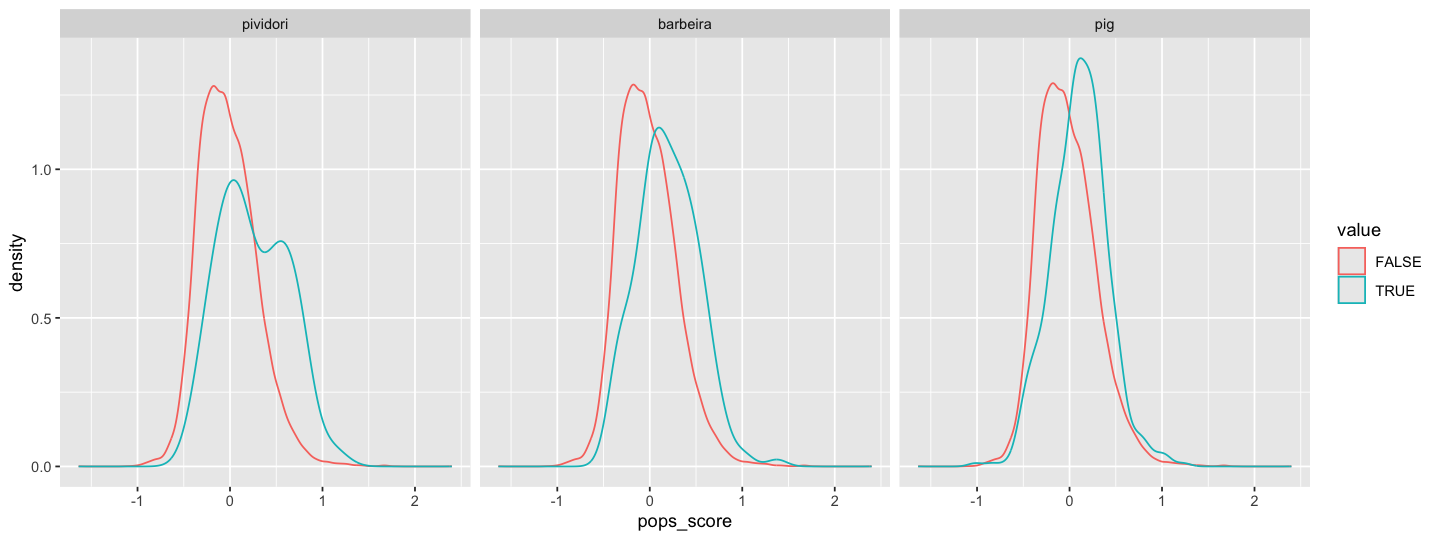

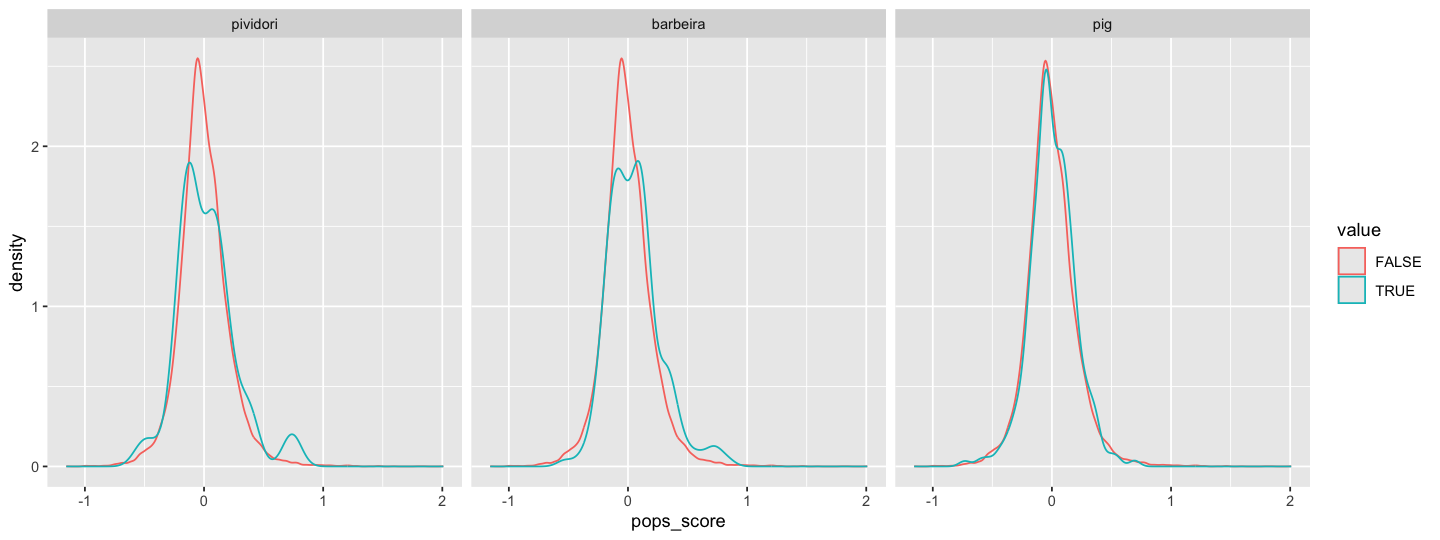

In [444]:
pops_enrichments('BMI', 'bmi')
print('')
pops_enrichments('ADHD', 'bmi')

[1] "No Pividori hits"
[1] 0.006754923
[1] 1.440429e-07
[1] ""
[1] "No Pividori hits"
[1] 0.7316996
[1] 0.449272


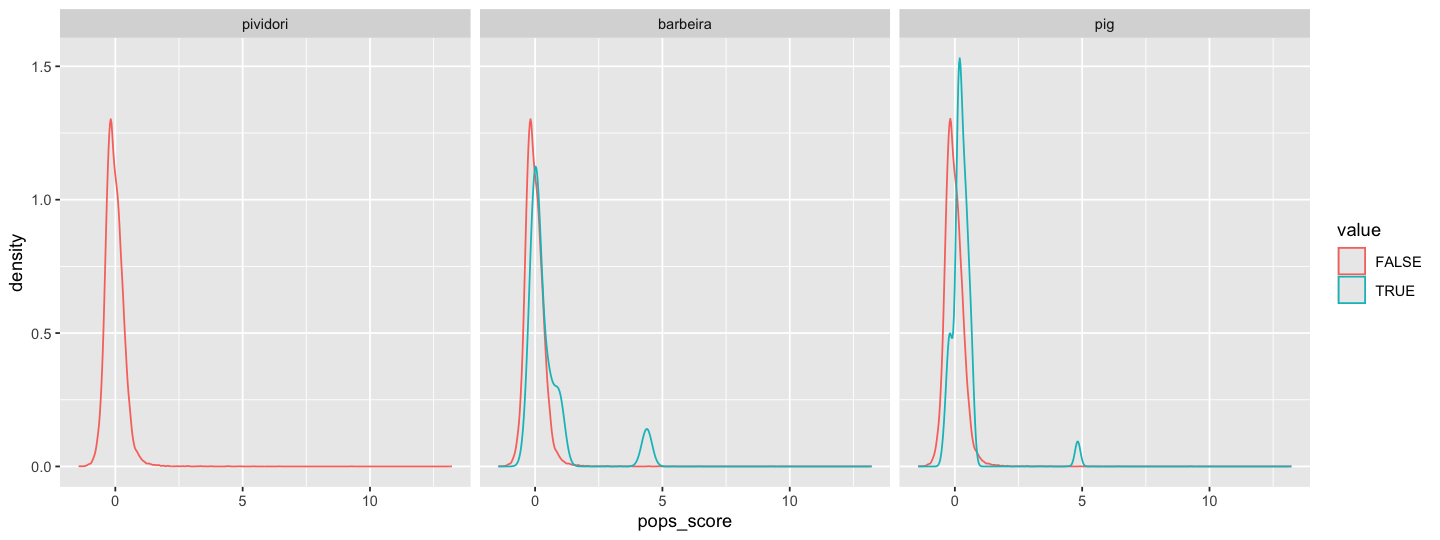

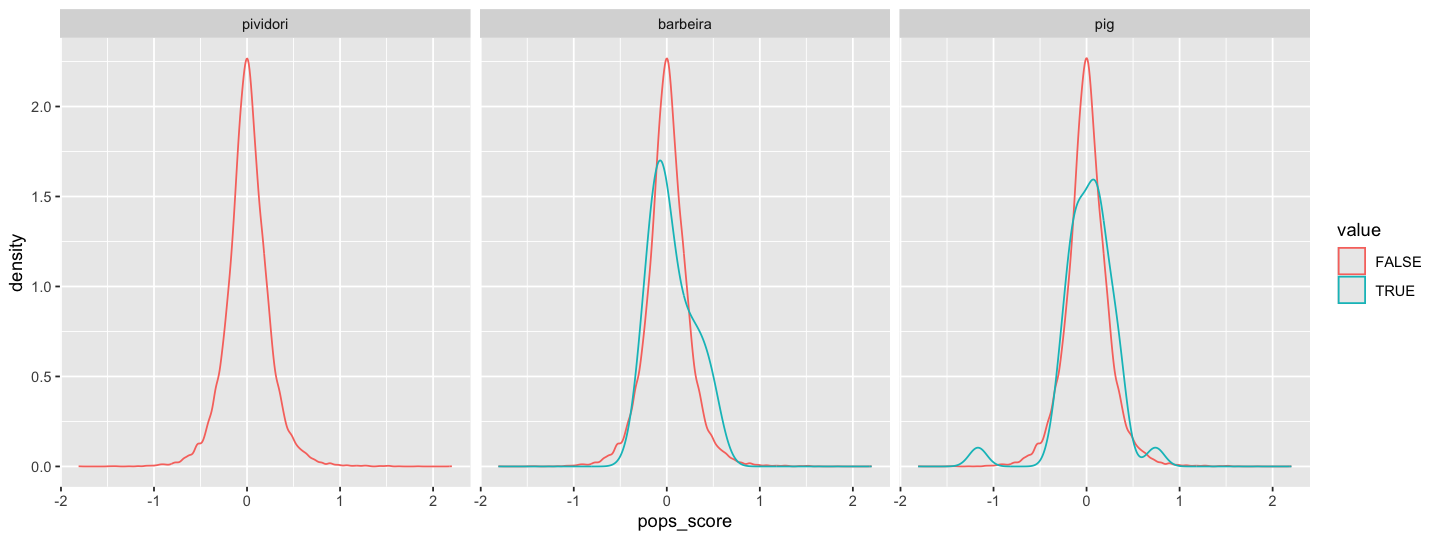

In [448]:
pops_enrichments('LDLC', 'ldl')
print('')
pops_enrichments('Bipolar_Disorder', 'ldl')

[1] 6.517034e-11
[1] 3.241902e-29
[1] 0.2044979
[1] ""
[1] 0.6929931
[1] 1.805347e-05
[1] 0.03823741


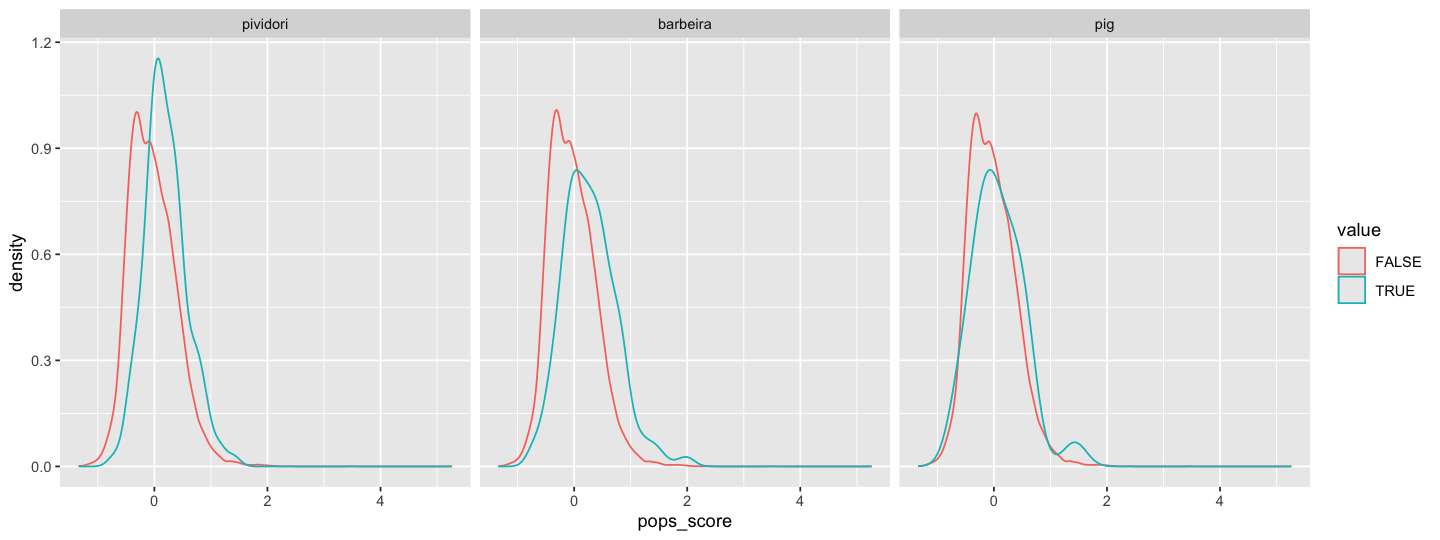

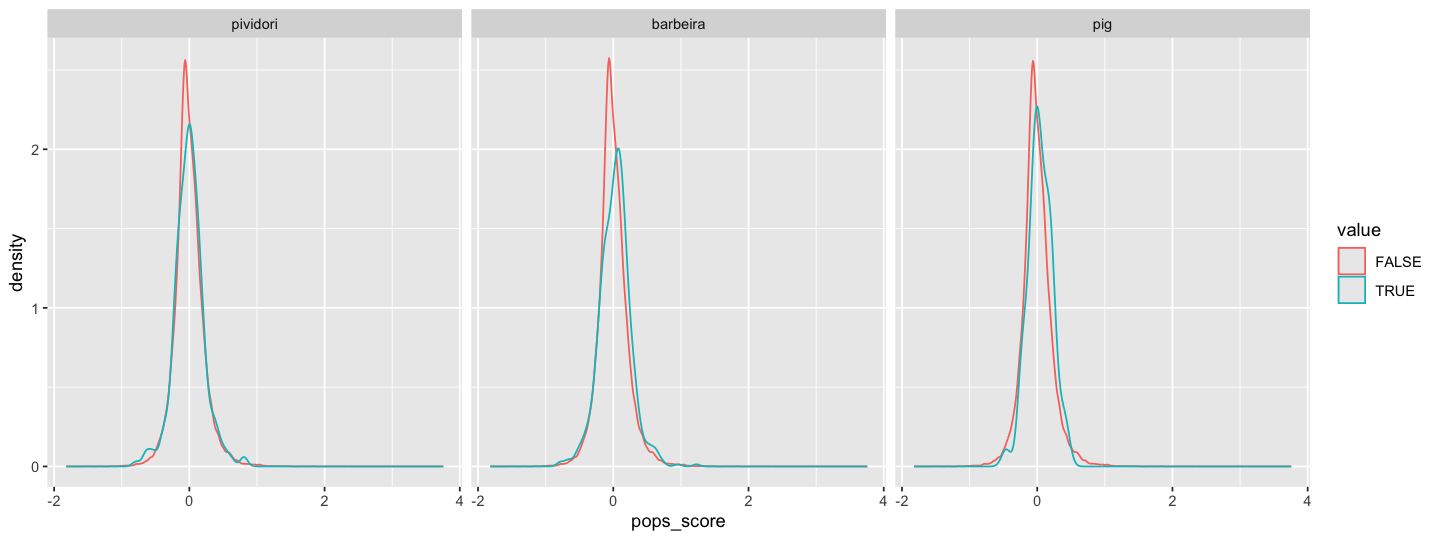

In [451]:
pops_enrichments('RBC', 'rbc_count')
print('')
pops_enrichments('Neuroticism', 'rbc_count')

[1] 1.178424e-07
[1] "No Barbeira hits"
[1] 2.794445e-07
[1] ""
[1] 0.02094843
[1] "No Barbeira hits"
[1] 0.000159901


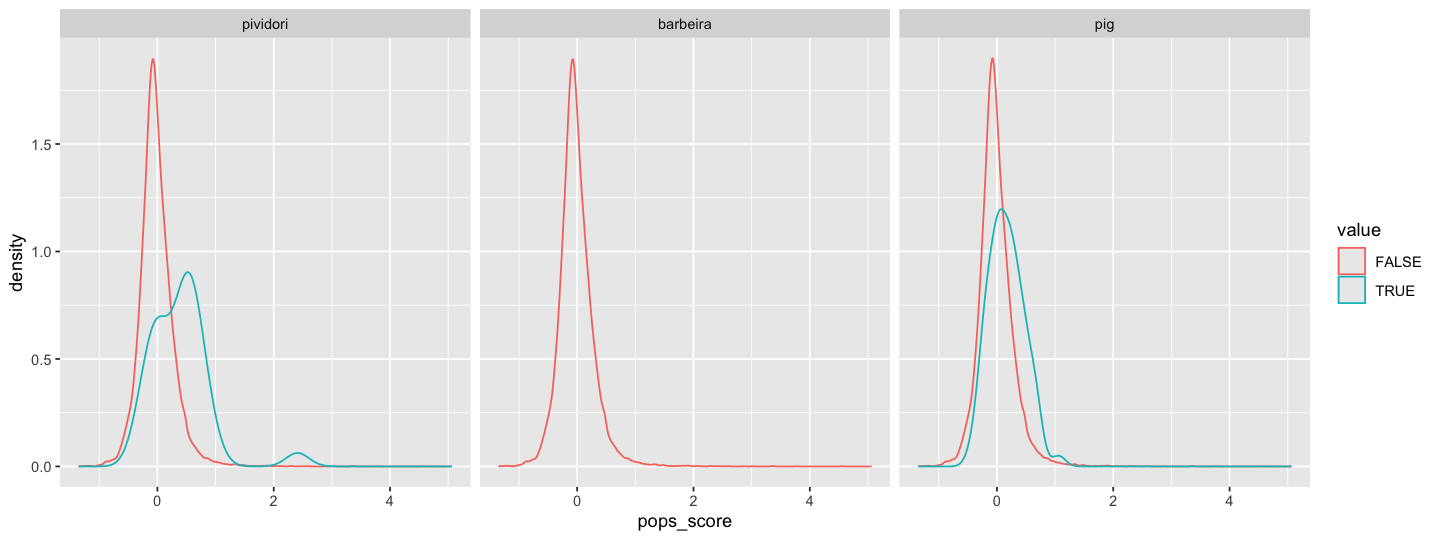

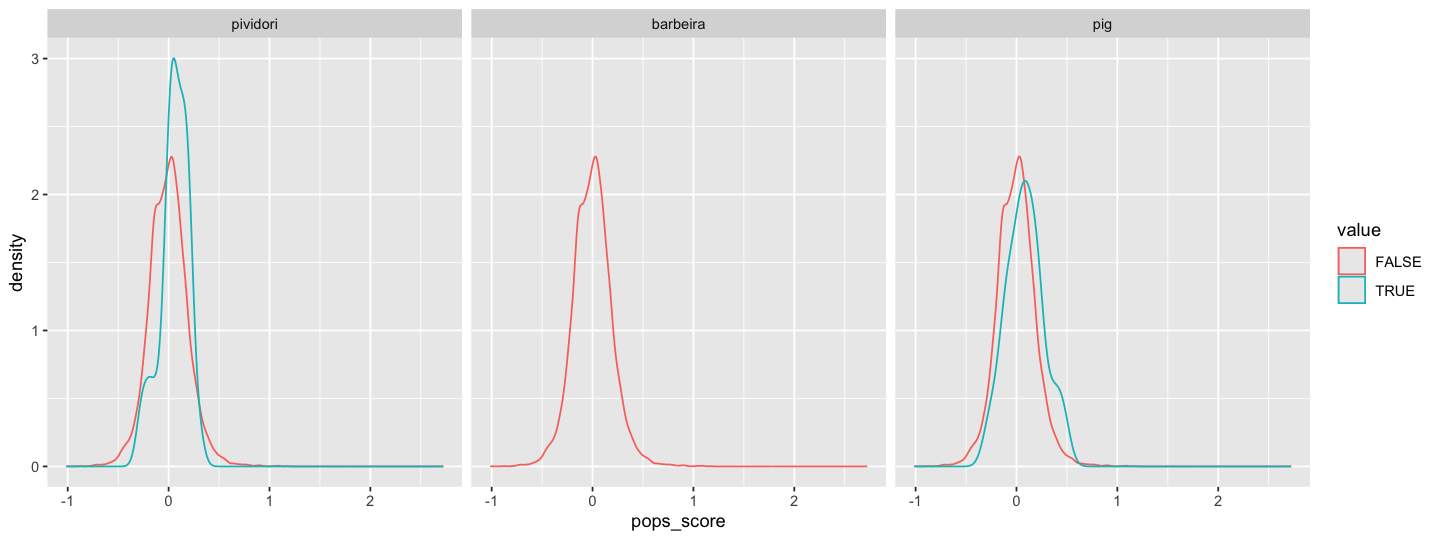

In [453]:
pops_enrichments('MCHC', 'mean_corpuscular_haemoglobin_concentration')
print('')
pops_enrichments('Schizophrenia', 'mean_corpuscular_haemoglobin_concentration')

[1] 3.680726e-11
[1] "No Barbeira hits"
[1] 7.65008e-39
[1] ""
[1] 0.3583276
[1] "No Barbeira hits"
[1] 0.0196245


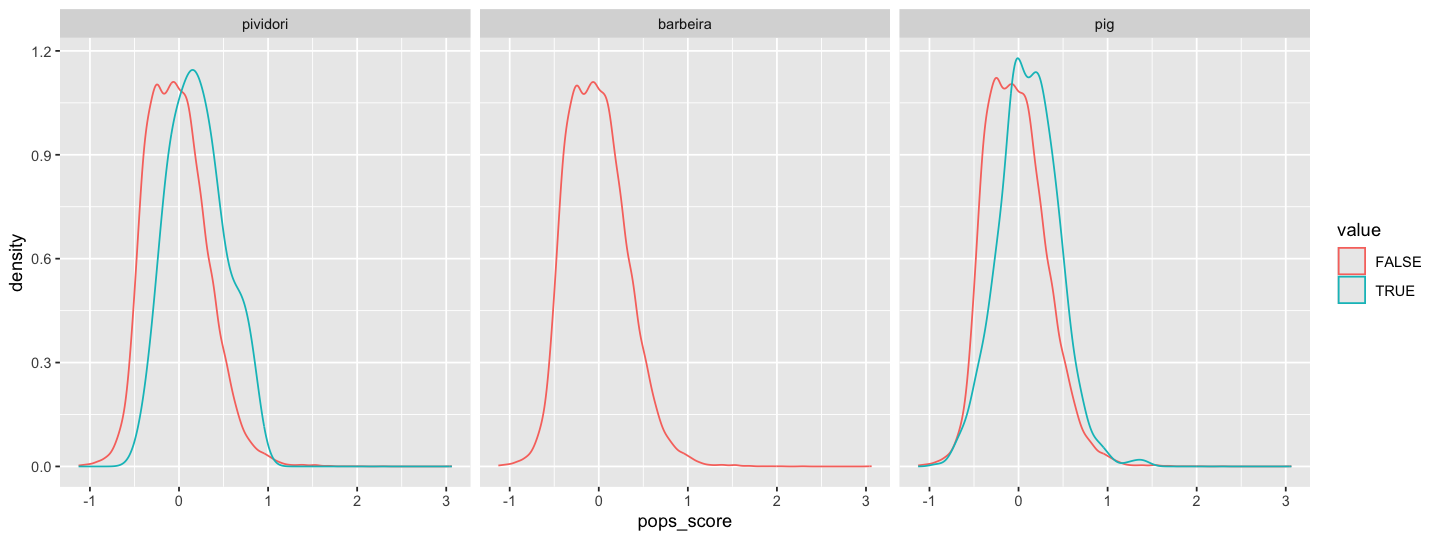

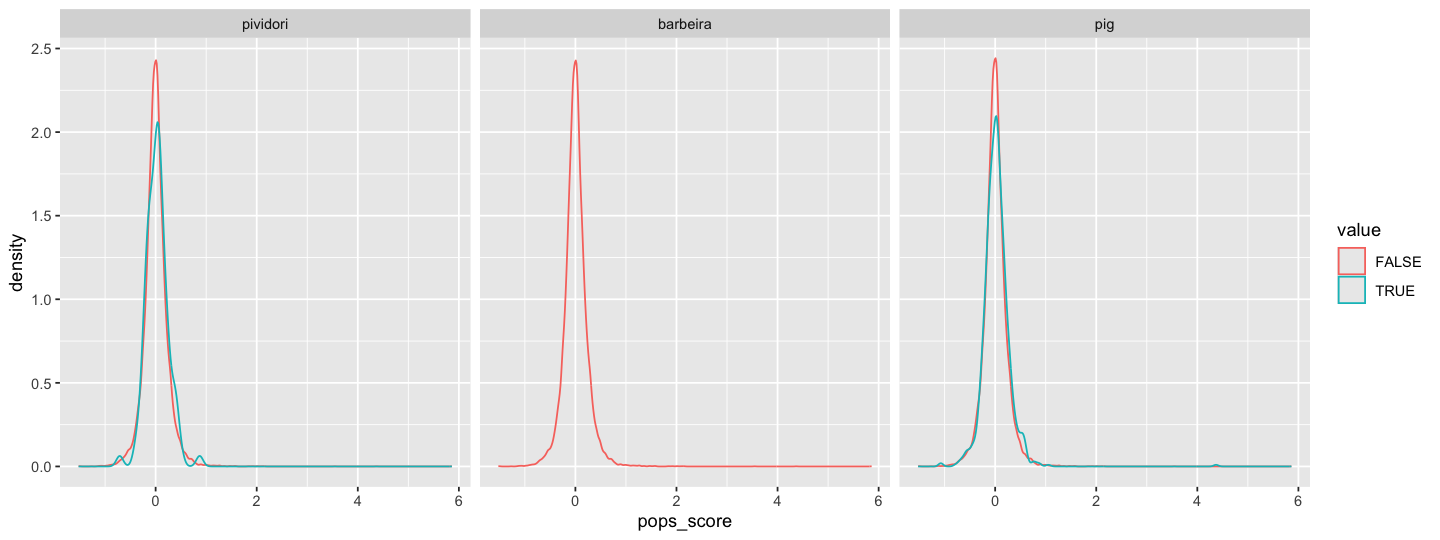

In [455]:
pops_enrichments('BW', 'weight')
print('')
pops_enrichments('Alzheimer', 'weight')